# 📘 Lecture 14: Multivariate Gaussian MLE, OLS Regression, Surrogate Losses, Method of Moments, & EWMA
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 14 - YouTube](https://youtu.be/JAj8z-UWqBA?si=7K2kyNMIyqogKI-r)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we continue our deep-dive into statistical estimation methods:
1. **Multivariate Gaussian MLE & Matrix Centering**: Deriving $\hat{\boldsymbol{\mu}}_{MLE} = \bar{\mathbf{y}}$ and covariance $\hat{\boldsymbol{\Sigma}}_{MLE} = \frac{1}{N} \mathbf{S}_{\bar{\mathbf{y}}} = \frac{1}{N} \mathbf{Y}^\top \mathbf{C}_N \mathbf{Y}$ via the matrix trace trick, and demonstrating the $N < D$ rank-deficiency singularity hazard.
2. **Linear Regression MLE & OLS**: Proving that minimizing RSS yields Ordinary Least Squares (OLS) $\hat{\mathbf{w}}_{OLS} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$.
3. **Surrogate Loss Functions**: Visualizing 0-1 loss, Log Loss $\log(1 + e^{-y\eta})$, and Hinge Loss $\max(0, 1 - y\eta)$ as convex upper bounds for gradient optimization.
4. **Method of Moments (MoM) vs. MLE**: Demonstrating MoM failure on $\text{Unif}(\theta_1, \theta_2)$ where MoM yields an inconsistent bound $\hat{\theta}_2 < y_{\max}$, whereas MLE yields exact tightest interval bounds $\hat{\theta}_1 = \min(y_n), \hat{\theta}_2 = \max(y_n)$.
5. **Online Recursive Estimation & EWMA**: Deriving recursive mean updates $\hat{\mu}_t = \hat{\mu}_{t-1} + \frac{1}{t}(y_t - \hat{\mu}_{t-1})$, exponentially weighted moving average $\hat{\mu}_t = \beta \hat{\mu}_{t-1} + (1-\beta)y_t$, and proving why bias correction $\frac{\hat{\mu}_t}{1 - \beta^t}$ is essential for early stream steps.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, linear algebra, and plotting libraries.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.0.2


## 1️⃣ Multivariate Gaussian MLE & Centering Matrix

### 1.1 Matrix Derivation & Scatter Matrix
For $N$ $D$-dimensional samples $\mathbf{y}_n \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$:
1. **Mean MLE**: $\hat{\boldsymbol{\mu}}_{MLE} = \bar{\mathbf{y}} = \frac{1}{N} \sum_{n=1}^N \mathbf{y}_n$.
2. **Covariance MLE via Matrix Trace Trick**:
   $$\text{NLL}(\boldsymbol{\mu}, \boldsymbol{\Lambda}) = -\frac{N}{2} \log |\boldsymbol{\Lambda}| + \frac{1}{2} \text{Tr}\left( \mathbf{S}_{\bar{\mathbf{y}}} \boldsymbol{\Lambda} \right)$$
   Setting derivative $\frac{\partial \text{NLL}}{\partial \boldsymbol{\Lambda}} = 0$ yields:
   $$\hat{\boldsymbol{\Sigma}}_{MLE} = \frac{1}{N} \mathbf{S}_{\bar{\mathbf{y}}} = \frac{1}{N} \mathbf{Y}^\top \mathbf{C}_N \mathbf{Y}$$
   where $\mathbf{C}_N = \mathbf{I}_N - \frac{1}{N} \mathbf{1}_N \mathbf{1}_N^\top$ is the $N \times N$ **Centering Matrix**.

### 1.2 Singularity Hazard when $N < D$
Since $\mathbf{S}_{\bar{\mathbf{y}}}$ is a sum of $N$ rank-1 outer products, if $N < D$, $\text{Rank}(\hat{\boldsymbol{\Sigma}}_{MLE}) \le N < D$. The estimated covariance matrix is **singular / non-invertible**!

In [2]:
# Code Verification of Multivariate Gaussian Centering Matrix & N < D Singularity
D_dim = 5
N_small = 3 # N < D => Singular!
np.random.seed(42)
Y_data = np.random.multivariate_normal(np.zeros(D_dim), np.eye(D_dim), size=N_small)

# Centering Matrix C_N
C_N = np.eye(N_small) - (1.0 / N_small) * np.ones((N_small, N_small))
Sigma_mle_centered = (1.0 / N_small) * (Y_data.T @ C_N @ Y_data)

rank_Sigma = np.linalg.matrix_rank(Sigma_mle_centered)
det_Sigma = np.linalg.det(Sigma_mle_centered)

print("📊 Multivariate Gaussian MLE Singularity Check (N=3, D=5):")
print(f"   Matrix Dimensions D:               {D_dim}")
print(f"   Sample Size N:                     {N_small}")
print(f"   Covariance Matrix Rank:            {rank_Sigma}  (Rank-Deficient!)")
print(f"   Covariance Determinant det(Σ_MLE): {det_Sigma:.6f}  (Singular / Non-Invertible!)")


📊 Multivariate Gaussian MLE Singularity Check (N=3, D=5):
   Matrix Dimensions D:               5
   Sample Size N:                     3
   Covariance Matrix Rank:            2  (Rank-Deficient!)
   Covariance Determinant det(Σ_MLE): 0.000000  (Singular / Non-Invertible!)


## 2️⃣ Linear Regression MLE & Ordinary Least Squares (OLS)

### 2.1 Closed-Form Derivation
Assuming Gaussian residuals $y_n = \mathbf{w}^\top \mathbf{x}_n + \epsilon_n$ with $\epsilon_n \sim \mathcal{N}(0, \sigma^2)$:
$$\text{NLL}(\mathbf{w}) = \frac{1}{2\sigma^2} \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 = \frac{1}{2\sigma^2} \left( \mathbf{w}^\top \mathbf{X}^\top \mathbf{X} \mathbf{w} - 2 \mathbf{w}^\top \mathbf{X}^\top \mathbf{y} + \mathbf{y}^\top \mathbf{y} \right)$$

Setting gradient $\nabla_{\mathbf{w}} \text{NLL} = 0$:
$$\mathbf{X}^\top \mathbf{X} \mathbf{w} - \mathbf{X}^\top \mathbf{y} = 0 \implies \hat{\mathbf{w}}_{OLS} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$


In [3]:
# Code Implementation & Verification of OLS Formula
N_samples = 100
true_w = np.array([2.5, -1.8])
X_mat = np.random.uniform(-2, 2, size=(N_samples, 2))
y_vec = X_mat @ true_w + np.random.normal(0, 0.5, size=N_samples)

# Closed-Form OLS Solution
w_ols = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y_vec

print("📊 OLS Regression Verification:")
print(f"   True Weight Vector w:   {true_w}")
print(f"   Estimated OLS w_hat:   {w_ols.round(4)}")


📊 OLS Regression Verification:
   True Weight Vector w:   [ 2.5 -1.8]
   Estimated OLS w_hat:   [ 2.4788 -1.8023]


## 3️⃣ Empirical Risk Minimization & Convex Surrogate Losses

### 3.1 Non-Convex 0-1 Loss vs. Convex Upper Bounds
- **0-1 Classification Loss**: $L_{01}(y, \eta) = \mathbb{I}(y \eta \le 0)$ (Non-smooth step function, NP-hard to optimize).
- **Log Loss (Binary Cross-Entropy)**: $L_{\text{log}}(y, \eta) = \log(1 + e^{-y \eta})$ (Convex upper bound used in Logistic Regression).
- **Hinge Loss**: $L_{\text{hinge}}(y, \eta) = \max(0, 1 - y \eta)$ (Convex upper bound used in Support Vector Machines).

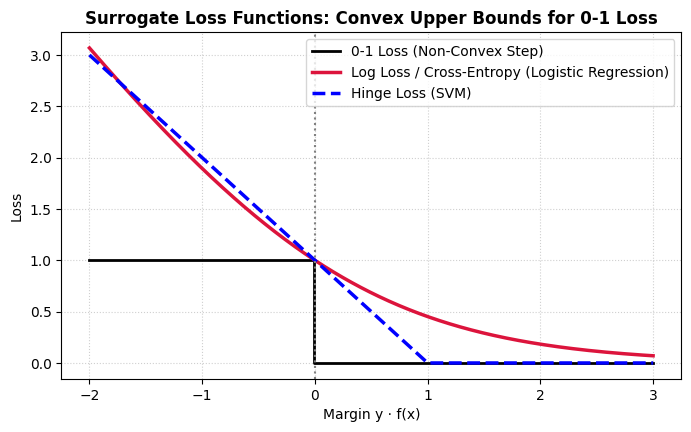

In [4]:
# Plotting 0-1 Loss vs. Log Loss vs. Hinge Loss
margin = np.linspace(-2.0, 3.0, 500) # y * f(x)

loss_01 = np.where(margin <= 0, 1.0, 0.0)
loss_log = np.log2(1.0 + np.exp(-margin)) # Normalized Log Loss
loss_hinge = np.maximum(0, 1.0 - margin)

plt.figure(figsize=(8, 4.5))
plt.step(margin, loss_01, color='black', linewidth=2, label='0-1 Loss (Non-Convex Step)')
plt.plot(margin, loss_log, color='crimson', linewidth=2.5, label='Log Loss / Cross-Entropy (Logistic Regression)')
plt.plot(margin, loss_hinge, color='blue', linewidth=2.5, linestyle='--', label='Hinge Loss (SVM)')

plt.axvline(0, color='gray', linestyle=':')
plt.xlabel('Margin y · f(x)')
plt.ylabel('Loss')
plt.title('Surrogate Loss Functions: Convex Upper Bounds for 0-1 Loss', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 4️⃣ Method of Moments (MoM) vs. MLE Failure Case Study

### 4.1 Uniform Distribution MoM Failure
Consider $Y \sim \text{Unif}(\theta_1, \theta_2)$ with sample data $\mathcal{D} = \{0, 0, 0, 0, 1\}$ ($N=5$):
- **MoM Equations**: Equating 1st and 2nd sample moments yields $\hat{\theta}_2^{MoM} = 0.893$.
  - **Inconsistency Failure**: Observed data point $1 > 0.893$, violating uniform probability bounds!
- **MLE Method**: Minimizing parameter width subject to containing all sample points:
  $$\hat{\theta}_1^{MLE} = \min(y_n) = 0.0, \quad \hat{\theta}_2^{MLE} = \max(y_n) = 1.0$$
  MLE provides the tightest valid interval containing all data.

In [5]:
# Simulation of Method of Moments (MoM) Failure on Uniform Distribution
y_unif_fail = np.array([0.0, 0.0, 0.0, 0.0, 1.0])

# Sample moments
mu1_hat = np.mean(y_unif_fail)    # 0.2
mu2_hat = np.mean(y_unif_fail**2) # 0.2

# MoM Parameter Estimates for Unif(theta1, theta2)
var_hat = mu2_hat - mu1_hat**2 # 0.2 - 0.04 = 0.16
diff_hat = np.sqrt(12.0 * var_hat) # sqrt(1.92) = 1.3856
theta1_mom = mu1_hat - 0.5 * diff_hat
theta2_mom = mu1_hat + 0.5 * diff_hat

# MLE Parameter Estimates
theta1_mle = np.min(y_unif_fail)
theta2_mle = np.max(y_unif_fail)

print("📊 Uniform Distribution MoM vs. MLE Comparison:")
print(f"   Dataset: {y_unif_fail}")
print(f"   MoM Estimates: θ1 = {theta1_mom:.3f}, θ2 = {theta2_mom:.3f}  (INCONSISTENT: Data point 1.0 > θ2!)")
print(f"   MLE Estimates: θ1 = {theta1_mle:.3f}, θ2 = {theta2_mle:.3f}  (VALID & TIGHTEST!)")


📊 Uniform Distribution MoM vs. MLE Comparison:
   Dataset: [0. 0. 0. 0. 1.]
   MoM Estimates: θ1 = -0.493, θ2 = 0.893  (INCONSISTENT: Data point 1.0 > θ2!)
   MLE Estimates: θ1 = 0.000, θ2 = 1.000  (VALID & TIGHTEST!)


## 5️⃣ Online Recursive Estimation & EWMA Bias Correction

### 5.1 Exponentially Weighted Moving Average (EWMA)
For streaming data arrival, the EWMA update rule is:
$$\hat{\mu}_t = \beta \hat{\mu}_{t-1} + (1 - \beta) y_t$$

### 5.2 Bias Correction Formula
Because $\hat{\mu}_0 = 0$, uncorrected EWMA estimates suffer from early-stage zero bias. Expanding $\hat{\mu}_t$:
$$\mathbb{E}[\hat{\mu}_t] = (1 - \beta^t) \mu \implies \hat{\mu}_t^{\text{corrected}} = \frac{\hat{\mu}_t}{1 - \beta^t}$$
Bias correction eliminates startup lag!

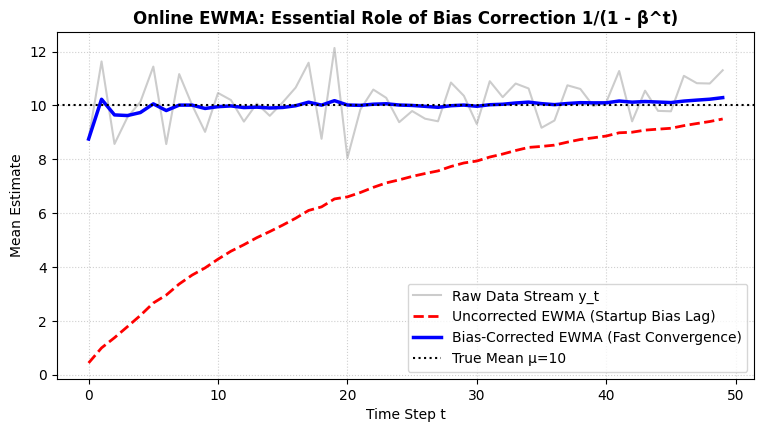

In [6]:
# Simulation of EWMA with Bias Correction
T_steps = 50
stream_data = np.random.normal(loc=10.0, scale=1.0, size=T_steps)
beta = 0.95 # High memory

mu_uncorrected = np.zeros(T_steps)
mu_corrected = np.zeros(T_steps)

running_mu = 0.0
for t in range(T_steps):
    y_t = stream_data[t]
    running_mu = beta * running_mu + (1.0 - beta) * y_t
    mu_uncorrected[t] = running_mu
    # Bias Correction
    mu_corrected[t] = running_mu / (1.0 - beta**(t+1))

plt.figure(figsize=(9, 4.5))
plt.plot(stream_data, color='gray', alpha=0.4, label='Raw Data Stream y_t')
plt.plot(mu_uncorrected, color='red', linestyle='--', linewidth=2, label='Uncorrected EWMA (Startup Bias Lag)')
plt.plot(mu_corrected, color='blue', linewidth=2.5, label='Bias-Corrected EWMA (Fast Convergence)')
plt.axhline(10.0, color='black', linestyle=':', label='True Mean μ=10')

plt.xlabel('Time Step t')
plt.ylabel('Mean Estimate')
plt.title('Online EWMA: Essential Role of Bias Correction 1/(1 - β^t)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 6️⃣ Master Summary Table
Below is a structured summary of all core concepts covered in Lecture 14.

In [7]:
# Master Concept Summary Table
summary_data = {
    "Concept": [
        "Univariate Gaussian Sufficient Stats",
        "Centering Matrix C_N",
        "Multivariate Gaussian Σ_MLE",
        "N < D Singularity Hazard",
        "Ordinary Least Squares (OLS)",
        "Convex Surrogate Losses",
        "Method of Moments (MoM)",
        "MoM Failure on Uniform",
        "EWMA Bias Correction"
    ],
    "Mathematical Formulation": [
        "(ybar, s^2) s.t. mu_hat = ybar, sigma^2_hat = s^2 - ybar^2",
        "C_N = I_N - (1/N) 1_N 1_N^T",
        "Σ_hat_MLE = (1/N) Y^T C_N Y",
        "Rank(Σ_hat_MLE) <= N < D => det(Σ_hat) = 0",
        "w_hat_OLS = (X^T X)^-1 X^T y",
        "L_log = log(1 + e^(-y eta)), L_hinge = max(0, 1 - y eta)",
        "mu_k(theta) = ybar_k => Solve parameter system",
        "MoM theta2_hat < y_max (Inconsistent) vs MLE theta2_hat = y_max",
        "mu_t_corrected = [beta mu_{t-1} + (1-beta)y_t] / (1 - beta^t)"
    ],
    "Key Takeaway / Application": [
        "Summarizes 100% data information without storing raw dataset",
        "Subtracts mean vector from every row matrix geometrically",
        "Empirical scatter matrix estimated via matrix trace trick",
        "Insufficient samples relative to dimension yields singular covariance",
        "Closed-form MLE solution minimizing Residual Sum of Squares (RSS)",
        "Smooth convex upper bounds replacing non-smooth 0-1 step loss",
        "Fast closed-form estimation by matching sample moments",
        "MoM can violate bounded distribution support; MLE provides tightest bound",
        "Eliminates zero-initialization startup lag in streaming updates"
    ]
}

df_master_l14 = pd.DataFrame(summary_data)
print("📌 Lecture 14 Master Summary Table:")
print(df_master_l14.to_string(index=False))


📌 Lecture 14 Master Summary Table:
                             Concept                                        Mathematical Formulation                                                Key Takeaway / Application
Univariate Gaussian Sufficient Stats      (ybar, s^2) s.t. mu_hat = ybar, sigma^2_hat = s^2 - ybar^2              Summarizes 100% data information without storing raw dataset
                Centering Matrix C_N                                     C_N = I_N - (1/N) 1_N 1_N^T                 Subtracts mean vector from every row matrix geometrically
         Multivariate Gaussian Σ_MLE                                     Σ_hat_MLE = (1/N) Y^T C_N Y                 Empirical scatter matrix estimated via matrix trace trick
            N < D Singularity Hazard                      Rank(Σ_hat_MLE) <= N < D => det(Σ_hat) = 0     Insufficient samples relative to dimension yields singular covariance
        Ordinary Least Squares (OLS)                                    w_hat_OLS = (X^T X